# Live RL — training **sheep** only (critic-free PPO)

Single-species version of `train.ipynb`. Only the **sheep** keep learning as they live: while
awake they collect on-policy experience, and when the sheep population beds down at night the
simulation **pauses** and one PPO update runs on the sheep policy alone. On waking, collection
resumes. The **fox** are *not* learning here — they are a fixed opponent that keeps the
ecosystem realistic (predator–prey pressure) while the sheep policy adapts against a
**stationary** environment (which is what makes single-species RL stable).

## The non-training species (fox) — pick one of two drivers

Set `OPPONENT` in the config cell:

- `"rule"` — the calibrated `RuleBrain` (see v1.md §18 / CLAUDE.md). This is the well-tuned
  teacher that makes predator–prey coexist, so the ecosystem stays in its known-good regime.
  **Recommended default** — a persistent, stationary opponent.
- `"model"` — an already-trained TorchScript policy for the fox (the imitation clone
  `../imitation_learning/fox.pt`, or a `fox_ppo.pt` you trained earlier). Loaded frozen via
  `sim.policy_brain` and never updated. Use this to fine-tune sheep against a *neural* fox.
  ⚠️ the raw imitation fox clone can be fragile (the cloned fox can die out through prey
  troughs) — if the fox collapses, the sheep train against an unrealistic world; prefer
  `"rule"` unless you have a robust fox checkpoint.

**Reward / pain** and **critic-free PPO** are exactly as in `train.ipynb` (all machinery lives
in `ppo_live.py`); only the sheep policy is optimised. The result re-exports as a drop-in
`sheep_ppo.pt` TorchScript archive for `run_experiment.py` / `run_live.py`.

In [1]:
# --- bootstrap: reach ppo_live.py (this folder) + the imitation toolkit + the repo root ---
import sys, time
from pathlib import Path

_HERE = Path.cwd()
for _c in (_HERE, *_HERE.parents):
    if (_c / "notebooks" / "live_learning" / "ppo_live.py").exists():
        _LIVE = _c / "notebooks" / "live_learning"
        break
    if (_c / "ppo_live.py").exists():
        _LIVE = _c
        break
else:
    raise RuntimeError("run this notebook from inside the ecosystem repo")
if str(_LIVE) not in sys.path:
    sys.path.insert(0, str(_LIVE))
_NB = _LIVE.parent                            # notebooks/ -- holds the shared common.py
if str(_NB) not in sys.path:
    sys.path.insert(0, str(_NB))

import numpy as np
import torch
import matplotlib.pyplot as plt

import ppo_live as P            # the PPO engine (imports common.py -> puts repo root on sys.path)
import common as C
from config import make_config, SHEEP, FOX, SPECIES_NAMES
from sim.simulation import Simulation
from sim.policy_brain import policy_brain_from_path   # frozen TorchScript opponent

print("torch", torch.__version__, "| cuda:", torch.cuda.is_available())

torch 2.11.0+cu128 | cuda: True


In [2]:
# --- configuration ---------------------------------------------------------------------
TRAIN  = SHEEP          # the species that LEARNS in this notebook
OTHER  = FOX          # the fixed (non-learning) opponent species

WORLD_SEED = 12345         # fixes the map (terrain + hydrology)
RUN_SEED   = 7             # fixes the sim dynamics RNG (action sampling adds its own noise)
DEVICE     = "cuda" if torch.cuda.is_available() else "cpu"

# ---- how the NON-training species (fox) is driven: "rule" or "model" ----
OPPONENT      = "model"                       # "rule" -> calibrated RuleBrain (recommended)
                                             # "model" -> a frozen trained policy (path below)
OPPONENT_PATH = C.MODEL_PATHS[OTHER]         # used only when OPPONENT == "model"
                                             # (imitation clone; or set to a *_ppo.pt you trained)

# how long to train.
#   An "epoch" == one full episode on the SAME world + run seed: the Simulation is rebuilt from
#     byte-identical initial conditions (make_config with the fixed WORLD_SEED/RUN_SEED), run
#     until the train species dies out or N_CYCLES day/night cycles elapse, then reset and run
#     again. Only the policy + optimizer (and torch's action-sampling RNG) carry across epochs,
#     so the sheep keep improving on repeated runs of the identical scenario. This is what lets
#     training survive an early extinction: the sim resets instead of the notebook stopping.
#   A "cycle"  == one day of collection + one night PPO update (~1 in-game day, ~240 ticks).
N_EPOCHS   = 30            # number of episodes (sim resets) to run; raise for a longer run
N_CYCLES   = 40            # max day/night cycles PER EPOCH before the sim is reset
MAX_TICKS  = 200_000       # per-epoch safety cap on sim ticks (guards a day that never ends)
SAVE_EVERY = 5             # export a deployable checkpoint every N cycles (counted across epochs)

# warm start the TRAIN species from its imitation clone (set to None to learn from scratch)
WARM_TRAIN = C.MODEL_PATHS[TRAIN]

# where the fine-tuned, deployable sheep policy is written (kept separate from the clone)
OUT_TRAIN = _LIVE / f"{SPECIES_NAMES[TRAIN]}_ppo.pt"

ppocfg = P.PPOConfig(
    gamma=0.99, clip=0.2, epochs=4, minibatch=1024, lr=1e-4,
    entropy_coef=0.005, max_grad_norm=0.5, target_kl=0.03,
    max_agents=128,        # trajectories tracked for the train species per day (bounds memory)
    night_hi=0.5,          # >= this fraction of sheep asleep  -> pause + train
    night_lo=0.2,          # <= this fraction of sheep asleep  -> daytime, resume collecting
    min_cycle=60,          # min ticks collected before a night trigger is allowed
    horizon=400,           # force a train if a day runs longer than this (safety)
)
rcfg = P.RewardConfig()    # reward/pain weights -- tweak freely

torch.manual_seed(RUN_SEED)   # reproducible action sampling (independent of the sim's numpy RNG)
assert OPPONENT in ("rule", "model")
print(f"training {SPECIES_NAMES[TRAIN]} | {SPECIES_NAMES[OTHER]} driven by: {OPPONENT}")
ppocfg, rcfg

training sheep | fox driven by: model


(PPOConfig(gamma=0.99, clip=0.2, epochs=4, minibatch=1024, lr=0.0001, entropy_coef=0.005, max_grad_norm=0.5, target_kl=0.03, max_agents=128, night_hi=0.5, night_lo=0.2, min_cycle=60, horizon=400),
 RewardConfig(survive_bonus=0.02, eat_gain_scale=4.0, drink_bonus=0.15, drink_thr=0.25, repro_bonus=2.0, health_gain_scale=1.0, need_penalty=0.02, death_penalty=2.0, age_death_frac=0.9))

In [3]:
# --- build the ONE learning policy + the fixed opponent (both PERSIST across epochs) ------
# the learner: a LivePPOBrain holding ONLY the train species' policy (warm-started). The policy,
# optimizer and buffer are created ONCE here and reused across every epoch -- that is how the
# sheep carry what they learned from one episode into the next. The Simulation itself is rebuilt
# inside the epoch loop below (from the same WORLD_SEED/RUN_SEED), and Simulation.__init__
# re-binds this same `brain` to the fresh entities each epoch.
policy = P.build_ppo_policy(TRAIN, warm_start=WARM_TRAIN, device=DEVICE)
optimizer = torch.optim.Adam(policy.parameters(), lr=ppocfg.lr)
buffer = P.RolloutBuffer(gamma=ppocfg.gamma, max_agents=ppocfg.max_agents)

brain = P.LivePPOBrain({TRAIN: policy}, device=DEVICE)   # drives the TRAIN species only
brain.training = True

# the opponent driver for the OTHER species:
#   "rule"  -> pass None, so Simulation fills it with a shared RuleBrain on the run RNG.
#   "model" -> a frozen PolicyBrain loaded from a TorchScript checkpoint (never updated).
if OPPONENT == "model":
    opponent = policy_brain_from_path(str(OPPONENT_PATH), OTHER, device=DEVICE)
    print("opponent:", OPPONENT_PATH)
else:
    opponent = None                                        # -> calibrated RuleBrain
    print("opponent: calibrated RuleBrain")

opponent: C:\Users\afree\Desktop\ecosystem\notebooks\imitation_learning\fox.pt


## The live training loop

**Outer loop — epochs (episodes).** Each epoch rebuilds the `Simulation` from the *same*
`WORLD_SEED` + `RUN_SEED`, so every epoch replays the byte-identical initial world. The
persistent `policy`/`optimizer`/`buffer` (and torch's action-sampling RNG) carry across
epochs, so the sheep keep improving on repeated runs of the identical scenario. An epoch ends
when the sheep go extinct, after `N_CYCLES` day/night cycles, or at the `MAX_TICKS` safety cap
— then the sim resets and the next epoch begins (instead of the notebook stopping on the first
extinction).

**Inner loop — cycles (days).** Same day/night state machine as before, keyed on the
**sheep**'s own sleep (the species we collect from):

- **Not collecting** → wait for sheep daybreak (`asleep_frac ≤ night_lo`), then start a day of
  collection.
- **Collecting** → each tick snapshot state → `sim.step()` (the sheep brain samples + records) →
  reward by snapshot-diff → file into the sheep buffer. When most sheep bed down
  (`asleep_frac ≥ night_hi`, after ≥ `min_cycle` ticks) — or the `horizon` safety — **pause and
  run one PPO update** on the sheep policy, clear the buffer, sleep through the night.

The fox act every tick from their fixed brain but are never recorded or updated. Sleeping /
dusk-straggler sheep whose action the sleep system overrides are dropped via the `controlled`
mask, exactly as before.

In [4]:
# --- run it: OUTER epoch loop over episodes of the SAME world ----------------------------
history = []       # per-cycle metrics across ALL epochs (each rec carries its 'epoch')
pop_log = []       # (epoch, tick, n_sheep, n_fox) every tick, for the population plot
global_cycle = 0   # cumulative completed cycles across epochs (drives SAVE_EVERY + plot x-axis)
t0 = time.time()
sim = None

for epoch in range(N_EPOCHS):
    # rebuild the sim from the SAME world + run seed -> byte-identical initial conditions each
    # epoch. Simulation.__init__ re-binds the persistent `brain` (policy) to the fresh entities;
    # the buffer is cleared so no experience leaks across an episode boundary.
    cfg = make_config(world_seed=WORLD_SEED, seed=RUN_SEED)
    sim = Simulation(cfg, brain={TRAIN: brain, OTHER: opponent})
    ent = sim.entities
    buffer.clear()
    epoch_start_tick = sim.tick
    collecting = False
    cycle = 0                            # per-epoch cycle index
    cycle_start = sim.tick
    print(f"\n=== epoch {epoch:3d}/{N_EPOCHS} | seeded: {sim.populations} ===")

    while cycle < N_CYCLES and (sim.tick - epoch_start_tick) < MAX_TICKS:
        snap = P.snapshot(ent)
        brain.collecting = collecting
        stats = sim.step()
        pop_log.append((epoch, sim.tick, stats["n_sheep"], stats["n_fox"]))

        # end this EPOCH (reset + continue) if the train species dies out or the world empties
        n_train = ent.count_species(TRAIN)
        if n_train == 0 or ent.n_alive == 0:
            print(f"  {SPECIES_NAMES[TRAIN]} went extinct @ tick {sim.tick} — ending epoch {epoch}")
            break

        # reward every TRAIN agent that acted this tick and file it into the buffer
        for sid, pend in brain.pending.items():          # pending holds only the TRAIN species
            r, done, controlled = P.compute_rewards(rcfg, snap, ent, pend)
            buffer.add(pend, r, done, controlled)

        # night detection follows the TRAIN species' own sleep (that's whose day we collect)
        tmask = ent.species_mask(TRAIN)
        n_asleep = int(ent.asleep[tmask].sum())
        asleep_frac = n_asleep / max(1, n_train)

        if not collecting:
            if asleep_frac <= ppocfg.night_lo:      # daybreak -> begin a new day of collection
                collecting = True
                cycle_start = sim.tick
        else:
            elapsed = sim.tick - cycle_start
            if elapsed >= ppocfg.min_cycle and (asleep_frac >= ppocfg.night_hi
                                                or elapsed >= ppocfg.horizon):
                # ---- NIGHT: pause the sim and run one PPO update on the TRAIN policy ----
                nm = SPECIES_NAMES[TRAIN]
                rec = {"epoch": epoch, "cycle": cycle, "global_cycle": global_cycle,
                       "tick": sim.tick, "day_len": elapsed,
                       "n_sheep": stats["n_sheep"], "n_fox": stats["n_fox"]}
                msg = [f"e{epoch:3d} c{cycle:3d} | tick {sim.tick:6d} | day {elapsed:3d}t | "
                       f"sheep {stats['n_sheep']:4d} fox {stats['n_fox']:3d}"]
                nt = buffer.n_transitions()
                batch = buffer.build_batch()
                if batch is None:
                    msg.append(f"    {nm:5s}: no data collected")
                else:
                    m = P.ppo_update(policy, optimizer, batch, ppocfg, device=DEVICE)
                    rec[f"{nm}_reward"] = float(batch["returns"].mean())
                    rec[f"{nm}_ploss"] = m["policy_loss"]
                    rec[f"{nm}_entropy"] = m["entropy"]
                    rec[f"{nm}_kl"] = m["approx_kl"]
                    rec[f"{nm}_n"] = nt
                    msg.append(f"    {nm:5s}: n={nt:6d} skip={buffer.skipped:6d} "
                               f"meanR={batch['returns'].mean():+.3f} "
                               f"ploss={m['policy_loss']:+.4f} ent={m['entropy']:.3f} "
                               f"kl={m['approx_kl']:.4f} clip={m['clipfrac']:.3f}")
                buffer.clear()
                history.append(rec)
                print("\n".join(msg))

                global_cycle += 1
                if global_cycle % SAVE_EVERY == 0:
                    P.export_policy(TRAIN, policy, OUT_TRAIN,
                                    meta={"epoch": epoch, "cycle": cycle, "global_cycle": global_cycle})
                    print(f"    [saved checkpoint @ epoch {epoch} cycle {cycle}]")

                collecting = False
                cycle += 1

final_pop = sim.populations if sim is not None else {}
print(f"\ndone: {N_EPOCHS} epochs, {global_cycle} cycles total, {time.time()-t0:.1f}s | "
      f"final {final_pop}")


=== epoch   0/30 | seeded: {'sheep': 240, 'fox': 24} ===
e  0 c  0 | tick    219 | day 186t | sheep  299 fox  24
    sheep: n= 22859 skip= 32913 meanR=+1.670 ploss=-0.0022 ent=2.420 kl=0.0091 clip=0.083
e  0 c  1 | tick    457 | day 186t | sheep  126 fox  14
    sheep: n= 14742 skip= 19016 meanR=+0.936 ploss=-0.0052 ent=2.358 kl=0.0084 clip=0.078
e  0 c  2 | tick    699 | day 189t | sheep  114 fox  19
    sheep: n= 19461 skip=  1796 meanR=+1.867 ploss=-0.0132 ent=2.345 kl=0.0076 clip=0.074
e  0 c  3 | tick    940 | day 188t | sheep  104 fox  21
    sheep: n= 21038 skip=  1023 meanR=+1.378 ploss=-0.0020 ent=2.403 kl=0.0062 clip=0.061
e  0 c  4 | tick   1177 | day 186t | sheep   69 fox   6
    sheep: n= 14034 skip=     0 meanR=+1.561 ploss=-0.0032 ent=2.367 kl=0.0055 clip=0.062
    [saved checkpoint @ epoch 0 cycle 4]
e  0 c  5 | tick   1417 | day 186t | sheep   75 fox   1
    sheep: n= 13214 skip=     0 meanR=+1.725 ploss=-0.0018 ent=2.391 kl=0.0060 clip=0.063
e  0 c  6 | tick   1657 |

KeyboardInterrupt: 

In [5]:
# --- export the final deployable sheep policy (drop-in TorchScript archive) ----------------
P.export_policy(TRAIN, policy, OUT_TRAIN,
                meta={"epochs": N_EPOCHS, "cycles": global_cycle, "world_seed": WORLD_SEED})
print("wrote", OUT_TRAIN)

_other_flag = (f"--{SPECIES_NAMES[OTHER]}-brain {OPPONENT_PATH} ") if OPPONENT == "model" else ""
print("\nDeploy with, e.g.:")
print(f"  venv/Scripts/python.exe run_experiment.py --ticks 3000 --world-seed {WORLD_SEED} "
      f"--seed {RUN_SEED} \\\n    --{SPECIES_NAMES[TRAIN]}-brain {OUT_TRAIN} {_other_flag}"
      f"--out runs/{SPECIES_NAMES[TRAIN]}_ppo_eval.csv --plot")

wrote c:\Users\afree\Desktop\ecosystem\notebooks\live_learning\sheep_ppo.pt

Deploy with, e.g.:
  venv/Scripts/python.exe run_experiment.py --ticks 3000 --world-seed 12345 --seed 7 \
    --sheep-brain c:\Users\afree\Desktop\ecosystem\notebooks\live_learning\sheep_ppo.pt --fox-brain C:\Users\afree\Desktop\ecosystem\notebooks\imitation_learning\fox.pt --out runs/sheep_ppo_eval.csv --plot


## Metrics

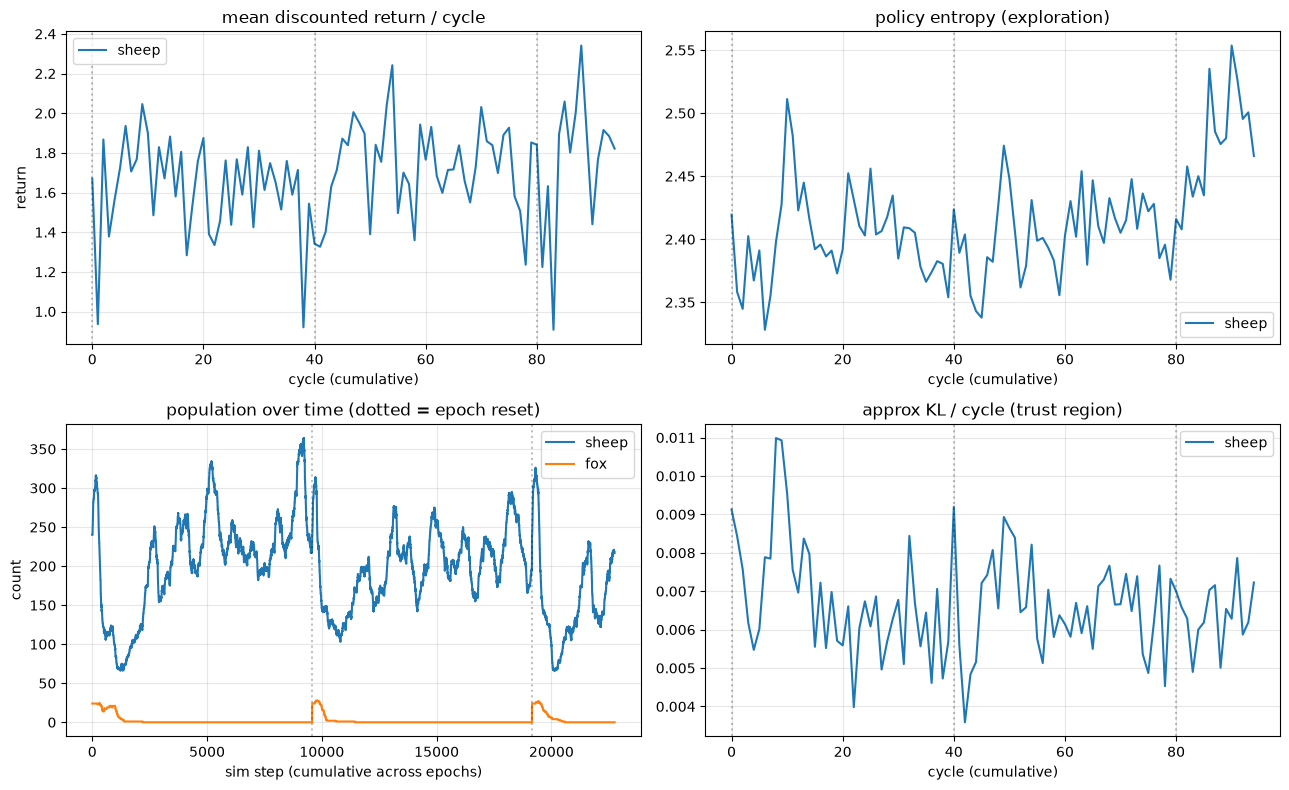

In [6]:
# --- learning curve (train species) + population dynamics ---------------------------------
if history:
    nm = SPECIES_NAMES[TRAIN]
    rk = f"{nm}_reward"; ek = f"{nm}_entropy"; kk = f"{nm}_kl"
    fig, ax = plt.subplots(2, 2, figsize=(13, 8))

    # x-axis = cumulative cycle across epochs (per-epoch `cycle` resets, so it would overlay)
    xs = [h["global_cycle"] for h in history if rk in h]
    ax[0, 0].plot(xs, [h[rk] for h in history if rk in h], label=nm)
    ax[0, 1].plot(xs, [h[ek] for h in history if ek in h], label=nm)
    ax[1, 1].plot(xs, [h[kk] for h in history if kk in h], label=nm)
    ax[0, 0].set(title="mean discounted return / cycle", xlabel="cycle (cumulative)", ylabel="return")
    ax[0, 0].legend(); ax[0, 0].grid(alpha=.3)
    ax[0, 1].set(title="policy entropy (exploration)", xlabel="cycle (cumulative)"); ax[0, 1].legend(); ax[0, 1].grid(alpha=.3)
    ax[1, 1].set(title="approx KL / cycle (trust region)", xlabel="cycle (cumulative)"); ax[1, 1].legend(); ax[1, 1].grid(alpha=.3)

    # epoch boundaries on the learning curves (a new episode/sim reset happens at each)
    for a in (ax[0, 0], ax[0, 1], ax[1, 1]):
        prev = None
        for h in history:
            if rk in h and h["epoch"] != prev:
                a.axvline(h["global_cycle"], color="k", ls=":", alpha=.25)
                prev = h["epoch"]

    if pop_log:
        # pop_log rows are (epoch, tick, n_sheep, n_fox); per-epoch tick resets, so plot against
        # a cumulative step index and draw a divider where each epoch (sim reset) begins.
        pl = np.array(pop_log)
        step = np.arange(len(pl))
        ax[1, 0].plot(step, pl[:, 2], label="sheep")
        ax[1, 0].plot(step, pl[:, 3], label="fox")
        epoch_starts = np.flatnonzero(np.diff(pl[:, 0]) != 0) + 1
        for s in epoch_starts:
            ax[1, 0].axvline(s, color="k", ls=":", alpha=.25)
        ax[1, 0].set(title="population over time (dotted = epoch reset)",
                     xlabel="sim step (cumulative across epochs)", ylabel="count")
        ax[1, 0].legend(); ax[1, 0].grid(alpha=.3)
    plt.tight_layout(); plt.show()
else:
    print("no cycles completed yet — run the training loop above")